In [2]:
import pandas as pd
import matplotlib.pyplot as plt

p1 = pd.read_parquet("data/interim/plant1.parquet")
p2 = pd.read_parquet("data/interim/plant2.parquet")
df = pd.concat([p1, p2], ignore_index=True)
df["date"] = df["DATE_TIME"].dt.date
df.describe().round(2)

,DATE_TIME,PLANT_ID,DC_POWER,AC_POWER,DAILY_YIELD,TOTAL_YIELD,AMBIENT_TEMPERATURE,MODULE_TEMPERATURE,IRRADIATION,plant
count,136476,136476.00,136476.00,136476.00,136476.00,1.364760e+05,136472.00,136472.00,136472.00,136476.0
mean,2020-06-01 09:23:03.157478,4135497.04,1708.54,274.80,3295.43,3.303821e+08,26.76,31.92,0.23,1.5
min,2020-05-15 00:00:00,4135001.00,0.00,0.00,0.00,0.000000e+00,20.40,18.14,0.00,1.0
25%,2020-05-23 23:00:00,4135001.00,0.00,0.00,28.32,6.520020e+06,23.64,22.41,0.00,1.0
50%,2020-06-01 18:45:00,4135001.00,6.05,3.51,2834.80,7.269333e+06,25.91,26.41,0.03,1.0
75%,2020-06-09 21:45:00,4136001.00,1155.79,532.67,5992.00,2.826096e+08,29.27,40.78,0.44,2.0
max,2020-06-17 23:45:00,4136001.00,14471.12,1410.95,9873.00,2.247916e+09,39.18,66.64,1.22,2.0
std,NaN,499.99,3222.18,380.18,3035.29,6.085705e+08,3.90,11.80,0.31,0.5


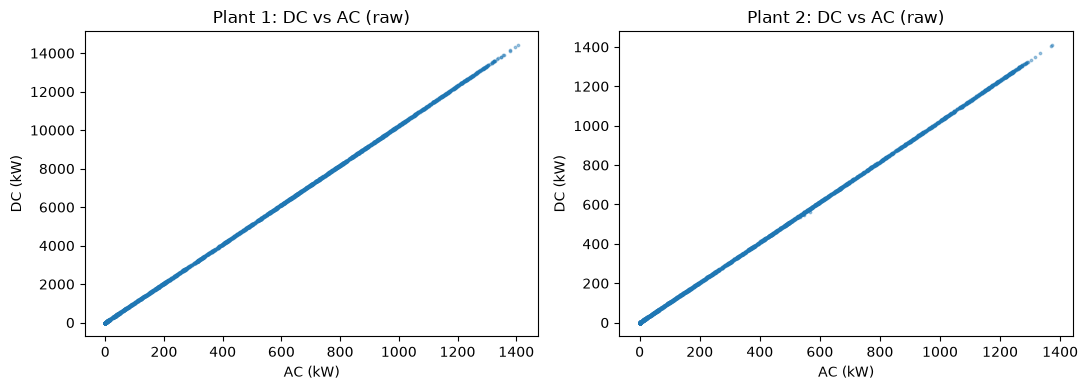

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
for ax, (p, g) in zip(axes, df.groupby("plant")):
    s = g.sample(5000, random_state=0)
    ax.scatter(s["AC_POWER"], s["DC_POWER"], s=3, alpha=0.4)
    ax.set(title=f"Plant {p}: DC vs AC (raw)", xlabel="AC (kW)", ylabel="DC (kW)")
plt.tight_layout()

In [4]:
df.loc[df["plant"] == 1, "DC_POWER"] *= 0.1

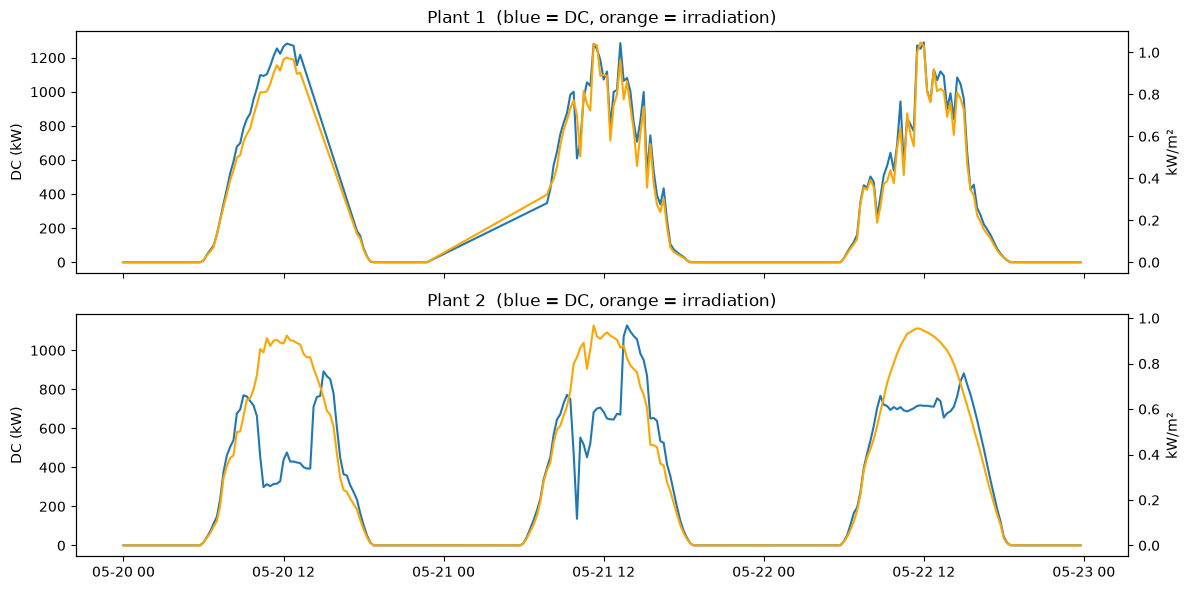

In [5]:
days = ["2020-05-20", "2020-05-21", "2020-05-22"]
fig, axes = plt.subplots(2, 1, figsize=(12, 6), sharex=True)
for ax, (p, g) in zip(axes, df.groupby("plant")):
    w = g[g["DATE_TIME"].dt.strftime("%Y-%m-%d").isin(days)]
    m = w.groupby("DATE_TIME")[["DC_POWER", "IRRADIATION"]].mean()
    ax.plot(m.index, m["DC_POWER"], label="mean DC")
    ax2 = ax.twinx()
    ax2.plot(m.index, m["IRRADIATION"], color="orange")
    ax.set_title(f"Plant {p}  (blue = DC, orange = irradiation)")
    ax.set_ylabel("DC (kW)")
    ax2.set_ylabel("kW/m²")
plt.tight_layout()

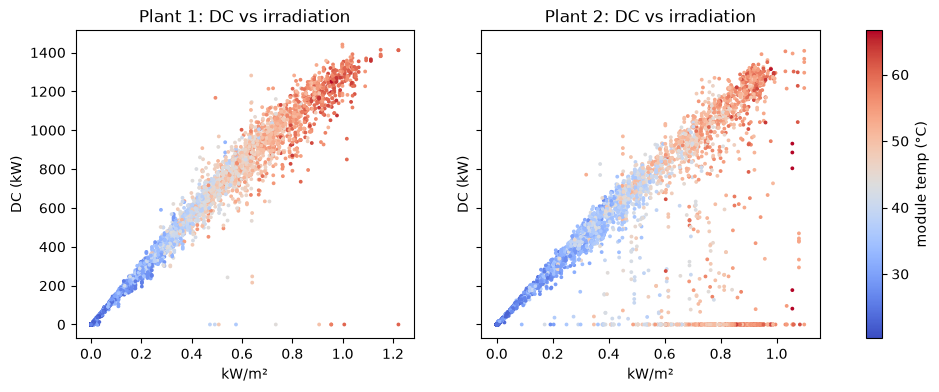

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharey=True)
for ax, (p, g) in zip(axes, df.groupby("plant")):
    s = g.sample(8000, random_state=0)
    sc = ax.scatter(s["IRRADIATION"], s["DC_POWER"],
                    c=s["MODULE_TEMPERATURE"], s=3, cmap="coolwarm")
    ax.set(title=f"Plant {p}: DC vs irradiation", xlabel="kW/m²", ylabel="DC (kW)")
fig.colorbar(sc, ax=axes, label="module temp (°C)")

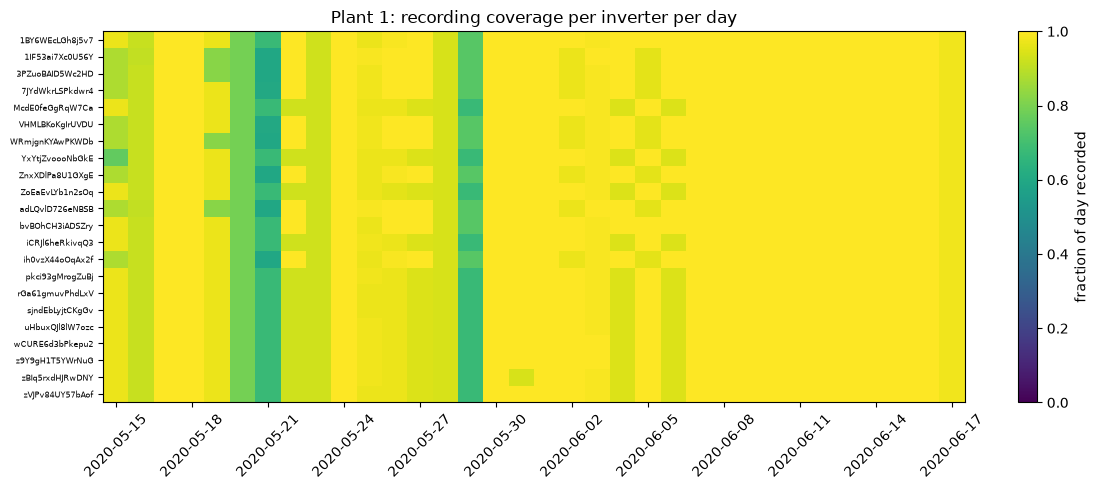

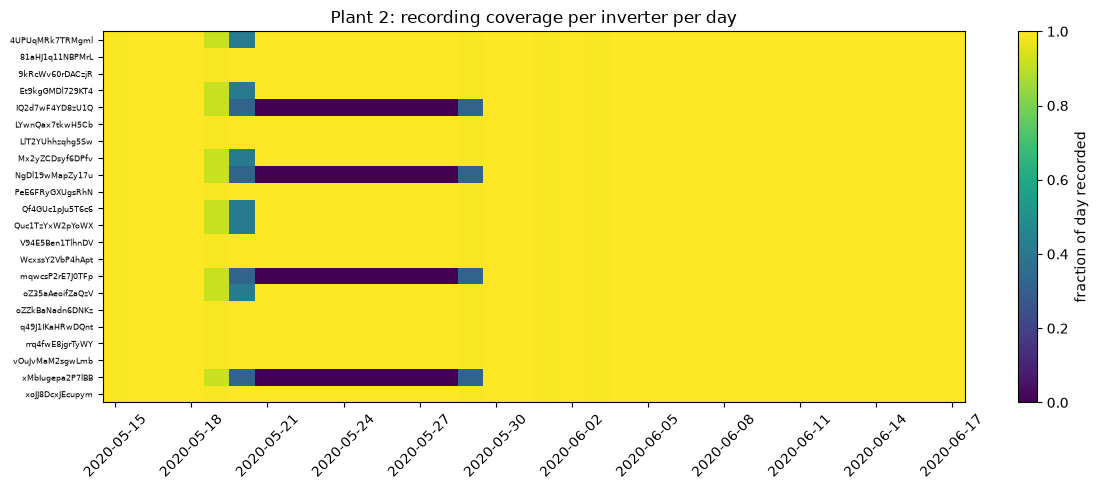

In [7]:
for p, g in df.groupby("plant"):
    cov = g.groupby(["SOURCE_KEY", "date"]).size().unstack(fill_value=0) / 96
    plt.figure(figsize=(12, 5))
    plt.imshow(cov, aspect="auto", cmap="viridis", vmin=0, vmax=1)
    plt.colorbar(label="fraction of day recorded")
    plt.yticks(range(len(cov)), cov.index, fontsize=6)
    plt.xticks(range(0, len(cov.columns), 3),
               [str(d) for d in cov.columns[::3]], rotation=45)
    plt.title(f"Plant {p}: recording coverage per inverter per day")
    plt.tight_layout()

<Axes: title={'center': 'Daily irradiation (kWh/m²)'}, xlabel='date'>

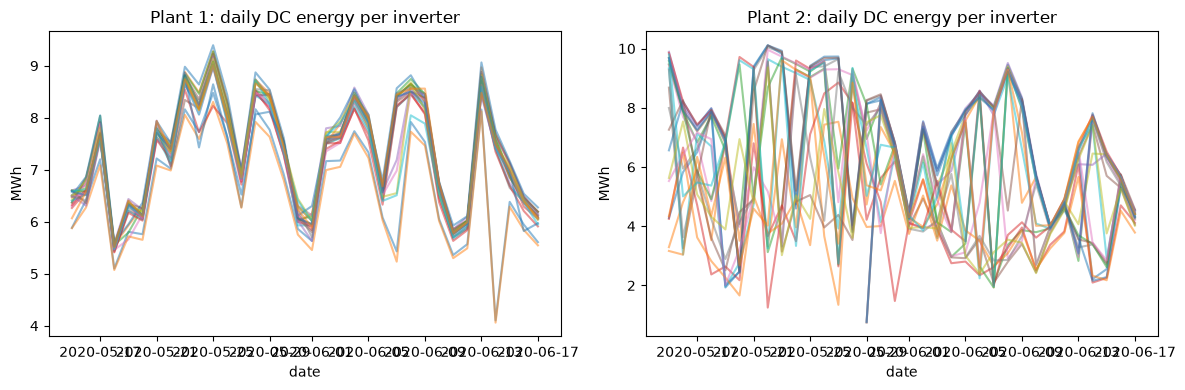

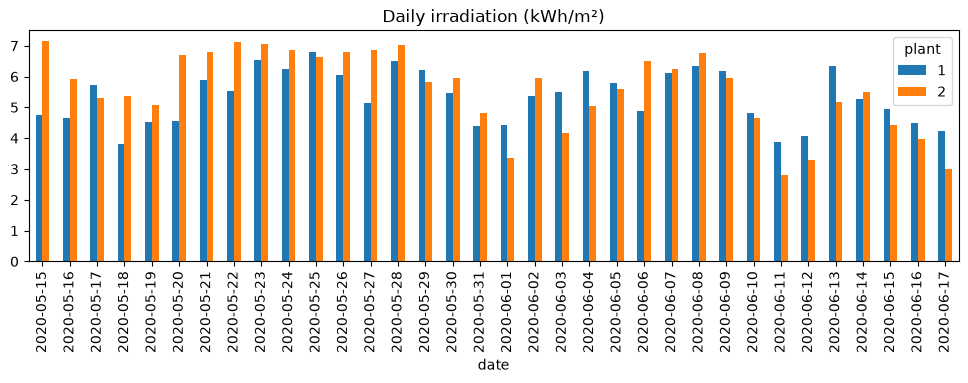

In [8]:
daily = df.groupby(["plant", "SOURCE_KEY", "date"])["DC_POWER"].sum() * 0.25 / 1000
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, p in zip(axes, [1, 2]):
    daily.loc[p].unstack("SOURCE_KEY").plot(ax=ax, legend=False, alpha=0.5)
    ax.set(title=f"Plant {p}: daily DC energy per inverter", ylabel="MWh")
plt.tight_layout()

wx = df.drop_duplicates(["plant", "DATE_TIME"])
(wx.groupby(["date", "plant"])["IRRADIATION"].sum().unstack() * 0.25).plot(
    kind="bar", figsize=(12, 3), title="Daily irradiation (kWh/m²)")

In [9]:
for p, g in df[df["IRRADIATION"] > 0].groupby("plant"):
    m = g.groupby("DATE_TIME")["DC_POWER"].mean()
    d = m.diff().abs().dropna()
    print(f"Plant {p}: 15-min |ΔDC| p50={d.median():.0f}  p95={d.quantile(0.95):.0f}  max={d.max():.0f} kW")

Plant 1: 15-min |ΔDC| p50=65  p95=339  max=1032 kW
Plant 2: 15-min |ΔDC| p50=49  p95=261  max=717 kW


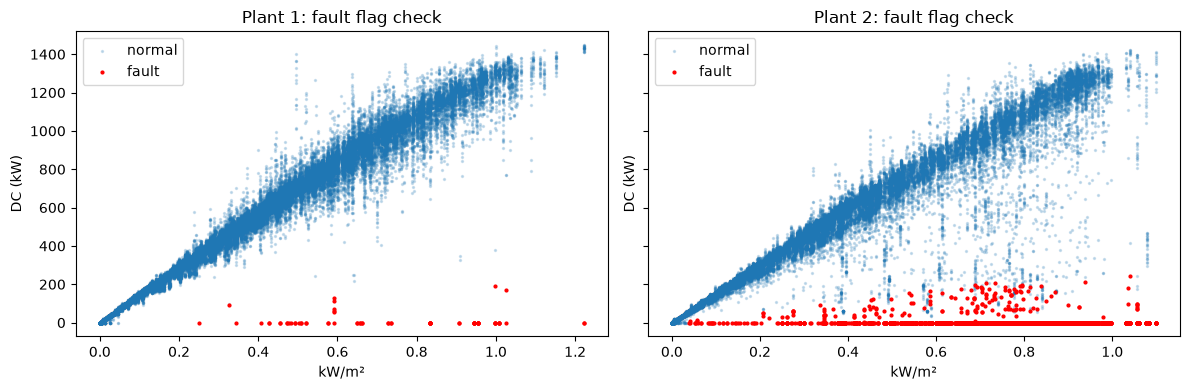

In [10]:
c = pd.concat([pd.read_parquet(f"data/interim/clean_plant{p}.parquet") for p in [1, 2]])
c = c[c["gen_observed"]]

fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharey=True)
for ax, (p, g) in zip(axes, c.groupby("plant")):
    ok, bad = g[~g["fault"]], g[g["fault"]]
    ax.scatter(ok["IRRADIATION"], ok["DC_POWER"], s=2, alpha=0.2, label="normal")
    ax.scatter(bad["IRRADIATION"], bad["DC_POWER"], s=4, color="red", label="fault")
    ax.set(title=f"Plant {p}: fault flag check", xlabel="kW/m²", ylabel="DC (kW)")
    ax.legend()
plt.tight_layout()